# 04 — Đánh giá HYBRID: giá cơ bản × hệ số nhân

**Kiến trúc đang đánh giá:**
```
giá cuối dự đoán = MODEL A (giá cơ bản) × MODEL B (hệ số nhân)
```

Notebook này **không train gì** — chỉ nạp lại dự đoán đã lưu từ 3 file train, ghép lại và so sánh
với **Hướng 1** (đoán thẳng giá cuối) để xác nhận kiến trúc Hybrid tốt hơn.

**Yêu cầu — chạy 3 file train trước:**
| File train | Sinh ra |
|---|---|
| `train/01_train_gia_co_ban.ipynb` | `pred_gia_co_ban.parquet` |
| `train/02_train_he_so_nhan.ipynb` | `pred_heso.parquet` |
| `train/03_train_gia_truc_tiep.ipynb` | `pred_gia.parquet` |

## 1. Nạp 3 file dự đoán

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 220)
BLUE, ORANGE, GREEN = "#0072B2", "#D55E00", "#009E73"

def metrics(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

for f, nb_goc in [("pred_gia_co_ban.parquet","01_train_gia_co_ban"),
                  ("pred_heso.parquet","02_train_he_so_nhan"),
                  ("pred_gia.parquet","03_train_gia_truc_tiep")]:
    assert Path(f).exists(), f"Chua co {f} -> chay train/{nb_goc}.ipynb truoc!"

base = pd.read_parquet("pred_gia_co_ban.parquet")
heso = pd.read_parquet("pred_heso.parquet")
truc_tiep = pd.read_parquet("pred_gia.parquet")

ALGOS = sorted(base.algo.unique())
thangs = sorted(base.evaluation_month.unique())
print(f"Model A (gia co ban) : {len(base):,} dong")
print(f"Model B (he so nhan) : {len(heso):,} dong")
print(f"Huong 1 (truc tiep)  : {len(truc_tiep):,} dong")
print(f"Thuat toan: {ALGOS} | Thang: {thangs}")

Model A (gia co ban) : 2,593,080 dong
Model B (he so nhan) : 2,593,080 dong
Huong 1 (truc tiep)  : 2,593,080 dong
Thuat toan: ['HistGB', 'LightGBM', 'XGBoost'] | Thang: ['2026-01', '2026-02', '2026-03']


## 2. Ghép Hybrid = giá cơ bản × hệ số nhân

Ghép theo **vị trí** trong từng (thuật toán × tháng) — 3 file train đều lấy `split=test` của cùng
tháng theo cùng thứ tự nên căn được theo vị trí.

In [2]:
hybrid_rows = []
for algo in ALGOS:
    for th in thangs:
        b = base[(base.algo==algo) & (base.evaluation_month==th)].reset_index(drop=True)
        h = heso[(heso.algo==algo) & (heso.evaluation_month==th)].reset_index(drop=True)
        assert len(b) == len(h), f"Lech so dong: {algo} {th} base={len(b)} heso={len(h)}"
        hybrid_rows.append(pd.DataFrame({
            "algo": algo, "evaluation_month": th,
            "gia_thuc": b.target_shown_price.values,
            "base_pred": b.base_pred.values,
            "heso_pred": h.pred.values,
            "hybrid_pred": b.base_pred.values * h.pred.values,
        }))
hybrid = pd.concat(hybrid_rows, ignore_index=True)
print(f"Da ghep Hybrid: {len(hybrid):,} dong")
print(hybrid.head(3).to_string())

Da ghep Hybrid: 2,593,080 dong
     algo evaluation_month  gia_thuc     base_pred  heso_pred    hybrid_pred
0  HistGB          2026-01  106000.0  87101.387739   1.152201  100358.305265
1  HistGB          2026-01  106000.0  87002.542326   1.170802  101862.731497
2  HistGB          2026-01  106000.0  86953.070681   1.163376  101159.145110


## 3. ⭐ So sánh Hybrid vs Hướng 1 (đoán thẳng giá cuối)

Cùng đánh giá trên `target_shown_price` (giá khách thực trả), cùng tập test.

In [3]:
TARGET = "target_shown_price"
rows = []
for algo in ALGOS:
    dh = hybrid[hybrid.algo==algo]
    d1 = truc_tiep[truc_tiep.algo==algo]
    for ten, y, p, dcol in [("Hybrid (co ban x he so)", dh.gia_thuc, dh.hybrid_pred, dh),
                            ("Huong 1 (truc tiep)", d1[TARGET], d1.pred, d1)]:
        rows.append({"Thuat toan": algo, "Phuong phap": ten, "Test-set": "TAT CA",
                     "n": len(dcol), **metrics(y, p)})
        for th in thangs:
            m = dcol.evaluation_month==th
            rows.append({"Thuat toan": algo, "Phuong phap": ten, "Test-set": th,
                         "n": int(m.sum()), **metrics(y[m], p[m])})
bang = pd.DataFrame(rows).round(2)
print("TONG GOP — Hybrid vs Huong 1:")
display(bang[bang["Test-set"]=="TAT CA"].sort_values("MAE"))
print("\nTung test-set nho theo thang:")
display(bang[bang["Test-set"]!="TAT CA"])

tong = bang[bang["Test-set"]=="TAT CA"]
best = tong.sort_values("MAE").iloc[0]
print(f"\nTot nhat: {best['Thuat toan']} + {best['Phuong phap']} (MAE={best['MAE']:,.0f} VND)")
print("(Tham chieu tuan 2: Hybrid MAE ~18.048 | Huong 1 MAE ~18.834)")

TONG GOP — Hybrid vs Huong 1:


,Thuat toan,Phuong phap,Test-set,n,MAE,RMSE,R2,MAPE
0,HistGB,Hybrid (co ban x he so),TAT CA,864360,18047.97,24533.96,0.73,14.74
8,LightGBM,Hybrid (co ban x he so),TAT CA,864360,18058.76,24548.54,0.73,14.75
16,XGBoost,Hybrid (co ban x he so),TAT CA,864360,18065.92,24568.27,0.73,14.76
20,XGBoost,Huong 1 (truc tiep),TAT CA,864360,18806.72,25602.59,0.71,15.34
12,LightGBM,Huong 1 (truc tiep),TAT CA,864360,18809.03,25607.87,0.71,15.34
4,HistGB,Huong 1 (truc tiep),TAT CA,864360,18834.01,25644.75,0.70,15.36



Tung test-set nho theo thang:


,Thuat toan,Phuong phap,Test-set,n,MAE,RMSE,R2,MAPE
1,HistGB,Hybrid (co ban x he so),2026-01,315360,17863.11,24331.19,0.73,14.78
2,HistGB,Hybrid (co ban x he so),2026-02,234632,17913.66,24288.23,0.73,14.73
3,HistGB,Hybrid (co ban x he so),2026-03,314368,18333.65,24916.03,0.73,14.72
5,HistGB,Huong 1 (truc tiep),2026-01,315360,18622.75,25327.14,0.71,15.44
6,HistGB,Huong 1 (truc tiep),2026-02,234632,18700.76,25422.74,0.71,15.34
7,HistGB,Huong 1 (truc tiep),2026-03,314368,19145.39,26121.93,0.70,15.29
9,LightGBM,Hybrid (co ban x he so),2026-01,315360,17880.00,24349.61,0.73,14.79
10,LightGBM,Hybrid (co ban x he so),2026-02,234632,17912.41,24279.40,0.73,14.73
11,LightGBM,Hybrid (co ban x he so),2026-03,314368,18347.33,24943.88,0.72,14.72
13,LightGBM,Huong 1 (truc tiep),2026-01,315360,18605.25,25306.00,0.71,15.42



Tot nhat: HistGB + Hybrid (co ban x he so) (MAE=18,048 VND)
(Tham chieu tuan 2: Hybrid MAE ~18.048 | Huong 1 MAE ~18.834)


## 4. Biểu đồ so sánh — 3 thuật toán × 2 phương pháp

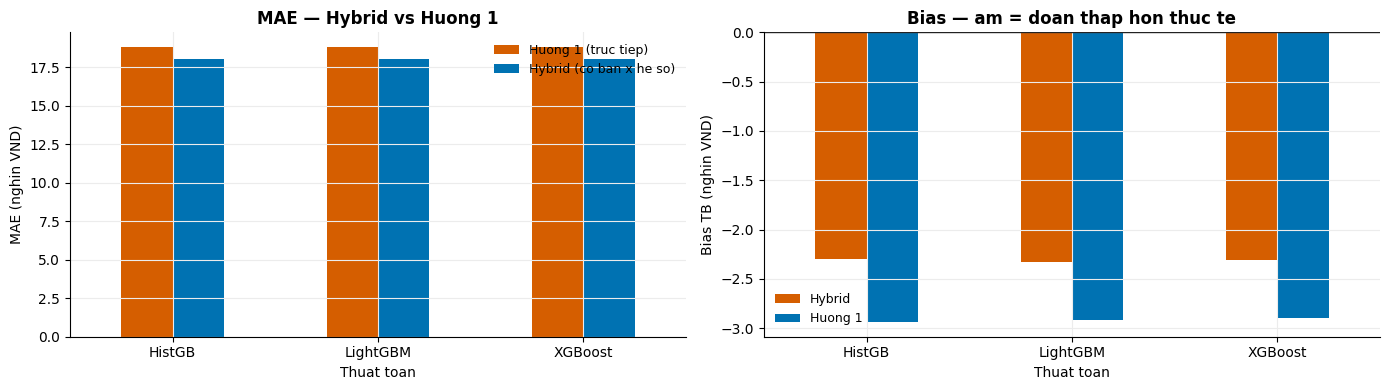

Bias trung binh (nghin VND):


,Hybrid,Huong 1
Thuat toan,,
HistGB,-2.30,-2.94
LightGBM,-2.33,-2.92
XGBoost,-2.31,-2.90


In [4]:
piv = tong.pivot(index="Thuat toan", columns="Phuong phap", values="MAE")/1000
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
piv.plot(kind="bar", ax=ax[0], color=[ORANGE, BLUE])
ax[0].set_ylabel("MAE (nghin VND)"); ax[0].set_title("MAE — Hybrid vs Huong 1", fontweight="bold")
ax[0].tick_params(axis="x", rotation=0); ax[0].legend(frameon=False, fontsize=9)

# Bias trung binh
bias_rows = []
for algo in ALGOS:
    dh = hybrid[hybrid.algo==algo]; d1 = truc_tiep[truc_tiep.algo==algo]
    bias_rows.append({"Thuat toan": algo,
                      "Hybrid": (dh.hybrid_pred - dh.gia_thuc).mean()/1000,
                      "Huong 1": (d1.pred - d1[TARGET]).mean()/1000})
bias_df = pd.DataFrame(bias_rows).set_index("Thuat toan")
bias_df.plot(kind="bar", ax=ax[1], color=[ORANGE, BLUE])
ax[1].axhline(0, color="#222", lw=1); ax[1].set_ylabel("Bias TB (nghin VND)")
ax[1].set_title("Bias — am = doan thap hon thuc te", fontweight="bold")
ax[1].tick_params(axis="x", rotation=0); ax[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("Bias trung binh (nghin VND):"); display(bias_df.round(2))

## 5. ⚠️ Rủi ro của Hybrid — độ ổn định từng chuyến

Hybrid thắng về **MAE trung bình** nhưng **rủi ro hơn ở từng chuyến lẻ**: khi cả 2 model cùng lệch
một chiều, sai số bị **nhân lên** thay vì cộng. Đo bằng độ lệch chuẩn và phân vị cao của sai số.

In [5]:
rows = []
for algo in ALGOS:
    dh = hybrid[hybrid.algo==algo]; d1 = truc_tiep[truc_tiep.algo==algo]
    for ten, ae in [("Hybrid", (dh.hybrid_pred-dh.gia_thuc).abs()),
                    ("Huong 1", (d1.pred-d1[TARGET]).abs())]:
        rows.append({"Thuat toan": algo, "Phuong phap": ten,
                     "MAE": ae.mean(), "Do lech chuan": ae.std(),
                     "P90": ae.quantile(0.90), "P99": ae.quantile(0.99),
                     "% sai >50k": (ae>50000).mean()*100})
on_dinh = pd.DataFrame(rows).round(2)
print("DO ON DINH SAI SO (cang nho cang on dinh):")
display(on_dinh)
print("\n-> Neu Hybrid co MAE thap hon nhung P99 / % sai >50k cao hon: thang trung binh, rui ro hon o duoi.")

DO ON DINH SAI SO (cang nho cang on dinh):


,Thuat toan,Phuong phap,MAE,Do lech chuan,P90,P99,% sai >50k
0,HistGB,Hybrid,18047.97,16618.85,38830.08,75900.07,4.79
1,HistGB,Huong 1,18834.01,17404.98,40573.07,79818.63,5.53
2,LightGBM,Hybrid,18058.76,16628.66,38858.61,75917.69,4.82
3,LightGBM,Huong 1,18809.03,17377.68,40488.75,79498.38,5.49
4,XGBoost,Hybrid,18065.92,16650.01,38879.75,75998.59,4.82
5,XGBoost,Huong 1,18806.72,17372.40,40500.36,79583.12,5.50



-> Neu Hybrid co MAE thap hon nhung P99 / % sai >50k cao hon: thang trung binh, rui ro hon o duoi.


## 6. Kết luận

Đọc từ bảng bước 3 và 5:

- **Bước 3** cho biết kiến trúc + thuật toán nào có MAE thấp nhất → lựa chọn cho pipeline chính.
- **Bước 4** cho biết bias (lệch có hướng). Bias âm = model đoán thấp hơn thực tế — đây là hiện tượng
  *shrinkage* thường gặp của regression trên phân phối lệch phải, đã thử smearing correction nhưng
  không cải thiện (xem báo cáo tuần 2).
- **Bước 5** là phần quan trọng khi triển khai thật: nếu Hybrid có P99/% sai lớn cao hơn Hướng 1 thì
  cần cân nhắc — thắng trung bình nhưng rủi ro hơn ở các chuyến cá biệt.